In [14]:
#Building a deep sigmoid net to visualize gradient norms per layer to see vanishing gradients in action

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

Device = torch.device("cuda:0:" if torch.cuda.is_available() else "cpu")

In [16]:
class DeepSigmoidNet(nn.Module):
    def __init__(self, input_dim =784, hidden_dim=64, num_layers=8, num_classes=10):
        super().__init__()
        layers = []

        #input layer
        layers.append(nn.Linear(input_dim, hidden_dim))

        #hidden layers
        for _ in range(num_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        #output layer
        layers.append(nn.Linear(hidden_dim, num_classes))

        #ModuleList: to loop across layers and access for gradient inspection
        self.layers = nn.ModuleList(layers) 

    def forward(self, x):
        x = x.view(x.size(0), -1)
        # all but laste use sigmoid
        for layer in self.layers[:-1]:
            x = torch.sigmoid(layer(x))
        x = self.layers[-1](x)
        return x

In [17]:
transform = transforms.ToTensor()
train_full = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

subset_indices = list(range(2000)) # small subset
train_subset = Subset(train_full, subset_indices)

train_dl = DataLoader(train_subset, batch_size=128, shuffle=True)
model = DeepSigmoidNet().to(Device)

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
num_epochs = 5

grad_history = []

for epoch in range(1, num_epochs +1):
    model.train()
    epoch_grad_norms = None

    for input, actual_output in train_dl:
        input, actual_output = input.to(Device), actual_output.to(Device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(input)
        loss = criterion(logits, actual_output)
        loss.backward()

        grad_norms = []
        for layer in model.layers:
            if layer.weight.grad is not None:
                grad_norms.append(layer.weight.grad.norm().item())
            else:
                grad_norms.append(0.0)
            
        epoch_grad_norms = grad_norms

        optimizer.step()

    grad_history.append(epoch_grad_norms)
    print(f"Epoch {epoch}: grad norms (last batch) = {epoch_grad_norms}")

Epoch 1: grad norms (last batch) = [2.2299914803625143e-08, 2.6207295888980298e-08, 1.928564614672723e-07, 1.4228054396880907e-06, 1.1154338608321268e-05, 7.686334720347077e-05, 0.0005530825583264232, 0.0036335368640720844, 0.031261611729860306, 0.2269486039876938]
Epoch 2: grad norms (last batch) = [2.2491677853508918e-08, 4.4610612093265445e-08, 3.135188535452471e-07, 2.28094404519652e-06, 1.9776958652073517e-05, 0.00013071643479634076, 0.0012453896924853325, 0.0094172153621912, 0.06681900471448898, 0.4770473837852478]
Epoch 3: grad norms (last batch) = [3.054475072872265e-08, 7.063766815917916e-08, 4.7057162078090187e-07, 3.765196197491605e-06, 2.787504854495637e-05, 0.00021851444034837186, 0.0016224358696490526, 0.012097425758838654, 0.08282654732465744, 0.5884861350059509]
Epoch 4: grad norms (last batch) = [2.4986670510429576e-08, 5.087949617177401e-08, 3.613551484704658e-07, 2.989811264342279e-06, 2.1505769836949185e-05, 0.0001677553227636963, 0.001173136057332158, 0.00867917109

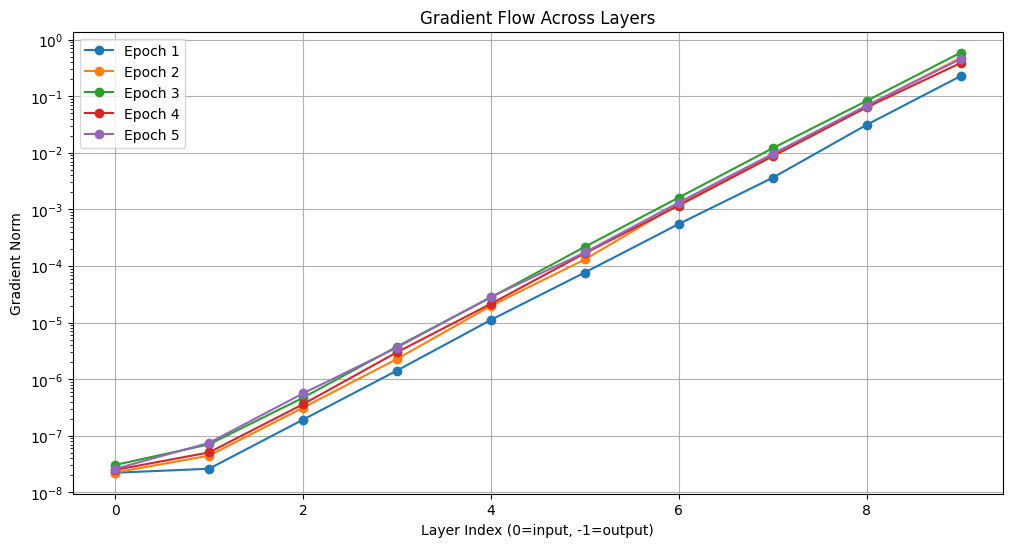

Final gradient norms by layer:
Layer 0: 0.000000
Layer 1: 0.000000
Layer 2: 0.000001
Layer 3: 0.000004
Layer 4: 0.000028
Layer 5: 0.000174
Layer 6: 0.001324
Layer 7: 0.009589
Layer 8: 0.068340
Layer 9: 0.454617


In [19]:
# Visualize gradient flow
plt.figure(figsize=(12, 6))

for epoch_idx, grad_norms in enumerate(grad_history):
    plt.plot(range(len(grad_norms)), grad_norms, 
             label=f'Epoch {epoch_idx+1}', marker='o')

plt.xlabel('Layer Index (0=input, -1=output)')
plt.ylabel('Gradient Norm')
plt.title('Gradient Flow Across Layers')
plt.legend()
plt.yscale('log')  # Log scale to see small gradients
plt.grid(True)
plt.show()

# Print final gradient norms
print("Final gradient norms by layer:")
for i, norm in enumerate(grad_history[-1]):
    print(f"Layer {i}: {norm:.6f}")


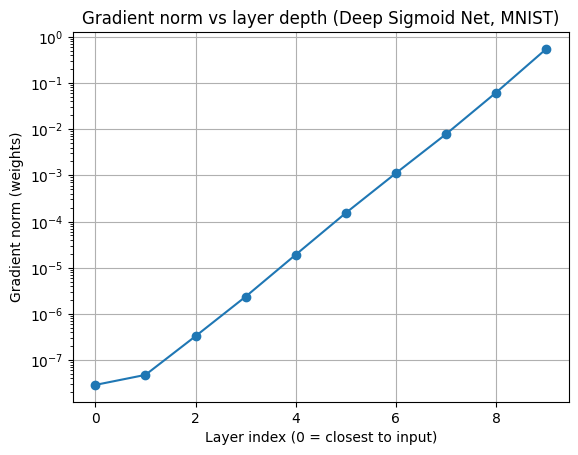

<Figure size 640x480 with 0 Axes>

In [13]:
import numpy as np

final_grads = grad_history[-1]  # last epoch
layer_indices = np.arange(len(final_grads))

plt.figure()
plt.plot(layer_indices, final_grads, marker="o")
plt.xlabel("Layer index (0 = closest to input)")
plt.ylabel("Gradient norm (weights)")
plt.yscale("log")  # clearer vanishing behavior
plt.title("Gradient norm vs layer depth (Deep Sigmoid Net, MNIST)")
plt.grid(True)
plt.show()
plt.savefig("grad_flow.png", bbox_inches="tight", dpi=200)